In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("midterm-regresi-dataset.csv", header=None)


df.columns = ["tahun"] + [f"fitur_{i}" for i in range(1, df.shape[1])]

display(df.head())
print("Shape:", df.shape)
print(df["tahun"].describe())

,tahun,fitur_1,fitur_2,fitur_3,fitur_4,fitur_5,fitur_6,fitur_7,fitur_8,fitur_9,...,fitur_81,fitur_82,fitur_83,fitur_84,fitur_85,fitur_86,fitur_87,fitur_88,fitur_89,fitur_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Shape: (515345, 91)
count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: tahun, dtype: float64


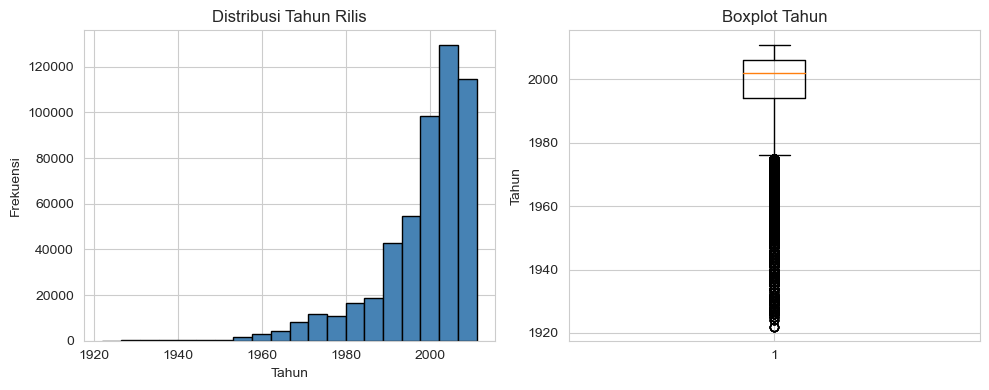

In [3]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["tahun"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribusi Tahun Rilis")
plt.xlabel("Tahun")
plt.ylabel("Frekuensi")

plt.subplot(1,2,2)
plt.boxplot(df["tahun"])
plt.title("Boxplot Tahun")
plt.ylabel("Tahun")

plt.tight_layout()
plt.show()


In [4]:
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


q_low = df_imputed.quantile(0.01)
q_hi  = df_imputed.quantile(0.99)
df_capped = df_imputed.clip(q_low, q_hi, axis=1)

display(df_capped.head())


,tahun,fitur_1,fitur_2,fitur_3,fitur_4,fitur_5,fitur_6,fitur_7,fitur_8,fitur_9,...,fitur_81,fitur_82,fitur_83,fitur_84,fitur_85,fitur_86,fitur_87,fitur_88,fitur_89,fitur_90
0,2001.0,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001.0,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001.0,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001.0,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001.0,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


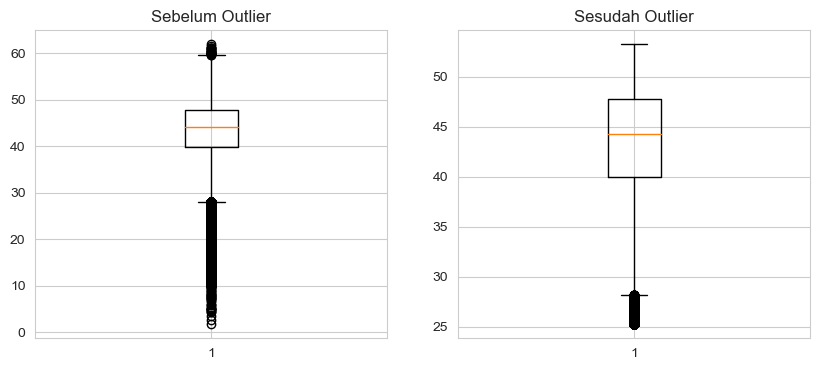

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df_imputed['fitur_1'])
axes[0].set_title('Sebelum Outlier')
axes[1].boxplot(df_capped['fitur_1'])
axes[1].set_title('Sesudah Outlier')
plt.show()

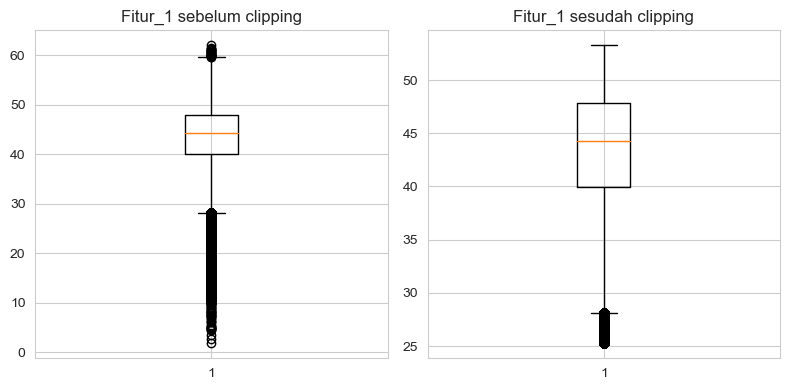

In [6]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.boxplot(df_imputed["fitur_1"])
plt.title("Fitur_1 sebelum clipping")

plt.subplot(1,2,2)
plt.boxplot(df_capped["fitur_1"])
plt.title("Fitur_1 sesudah clipping")

plt.tight_layout()
plt.show()


In [7]:
X = df_capped.drop("tahun", axis=1)
y = df_capped["tahun"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)


Train shape: (412276, 90)
Test shape : (103069, 90)


In [8]:
ridge_base = Ridge()

param_grid = {
    "alpha": [0.1, 1.0, 10.0, 100.0]
}

grid_ridge = GridSearchCV(
    ridge_base,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_ridge.fit(X_train_scaled, y_train)

print("Best alpha Ridge:", grid_ridge.best_params_)
print("Best CV R²     :", grid_ridge.best_score_)

ridge_best = grid_ridge.best_estimator_
ridge_preds = ridge_best.predict(X_test_scaled)


Best alpha Ridge: {'alpha': 100.0}
Best CV R²     : 0.2543528358780588


In [9]:
def build_nn(units1=128, units2=64, units3=32, lr=1e-3, dropout_rate=0.2, use_batchnorm=True):
    layers_list = [layers.Input(shape=(X_train.shape[1],))]

    # Dense 1
    layers_list.append(layers.Dense(units1, activation="relu"))
    if use_batchnorm:
        layers_list.append(layers.BatchNormalization())
    layers_list.append(layers.Dropout(dropout_rate))

    # Dense 2
    layers_list.append(layers.Dense(units2, activation="relu"))
    if use_batchnorm:
        layers_list.append(layers.BatchNormalization())
    layers_list.append(layers.Dropout(dropout_rate))

    # Dense 3
    layers_list.append(layers.Dense(units3, activation="relu"))

    # Output
    layers_list.append(layers.Dense(1))

    model = models.Sequential(layers_list)
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model


In [10]:
configs = [
    # units1, units2, units3, lr, dropout
    {"units1": 128, "units2": 64,  "units3": 32,  "lr": 1e-3, "dropout": 0.2},
    {"units1": 256, "units2": 128, "units3": 64,  "lr": 1e-3, "dropout": 0.2},
    {"units1": 128, "units2": 64,  "units3": 32,  "lr": 1e-4, "dropout": 0.1},
]

results_nn = []

for i, cfg in enumerate(configs):
    print(f"\n=== Config {i+1}: {cfg} ===")
    model = build_nn(
        units1=cfg["units1"],
        units2=cfg["units2"],
        units3=cfg["units3"],
        lr=cfg["lr"],
        dropout_rate=cfg["dropout"],
        use_batchnorm=True
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        verbose=0,
        callbacks=[early_stop]
    )

    preds = model.predict(X_test_scaled).flatten()
    r2  = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    print(f"R²: {r2:.3f}, MSE: {mse:.2f}")

    results_nn.append({
        "cfg": cfg,
        "r2": r2,
        "mse": mse,
        "history": history,
        "model": model
    })

results_nn



=== Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'lr': 0.001, 'dropout': 0.2} ===
3221/3221 [==============================] - 4s 1ms/step
R²: 0.372, MSE: 70.42

=== Config 2: {'units1': 256, 'units2': 128, 'units3': 64, 'lr': 0.001, 'dropout': 0.2} ===
3221/3221 [==============================] - 5s 1ms/step
R²: 0.381, MSE: 69.42

=== Config 3: {'units1': 128, 'units2': 64, 'units3': 32, 'lr': 0.0001, 'dropout': 0.1} ===
3221/3221 [==============================] - 4s 1ms/step
R²: 0.165, MSE: 93.57


[{'cfg': {'units1': 128,
   'units2': 64,
   'units3': 32,
   'lr': 0.001,
   'dropout': 0.2},
  'r2': 0.37176581106485507,
  'mse': 70.41884934639715,
  'history': <keras.callbacks.History at 0x255101155b0>,
  'model': <keras.engine.sequential.Sequential at 0x2550dddbd60>},
 {'cfg': {'units1': 256,
   'units2': 128,
   'units3': 64,
   'lr': 0.001,
   'dropout': 0.2},
  'r2': 0.38063915537836635,
  'mse': 69.42423506494428,
  'history': <keras.callbacks.History at 0x25550c554c0>,
  'model': <keras.engine.sequential.Sequential at 0x25550bd7850>},
 {'cfg': {'units1': 128,
   'units2': 64,
   'units3': 32,
   'lr': 0.0001,
   'dropout': 0.1},
  'r2': 0.16524539491714574,
  'mse': 93.56774879790746,
  'history': <keras.callbacks.History at 0x25572857160>,
  'model': <keras.engine.sequential.Sequential at 0x255728274f0>}]

In [11]:
# pilih berdasarkan R² tertinggi
best_idx = np.argmax([r["r2"] for r in results_nn])
best_entry = results_nn[best_idx]
best_cfg   = best_entry["cfg"]
print("Best NN config:", best_cfg)
print("Best R²      :", best_entry["r2"])

nn_best = build_nn(
    units1=best_cfg["units1"],
    units2=best_cfg["units2"],
    units3=best_cfg["units3"],
    lr=best_cfg["lr"],
    dropout_rate=best_cfg["dropout"],
    use_batchnorm=True
)

early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_best = nn_best.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1,              # print tiap epoch
    callbacks=[early_stop_final]
)

nn_preds = nn_best.predict(X_test_scaled).flatten()


Best NN config: {'units1': 256, 'units2': 128, 'units3': 64, 'lr': 0.001, 'dropout': 0.2}
Best R²      : 0.38063915537836635
Epoch 1/100
11596/11596 [==============================] - 41s 3ms/step - loss: 123723.8125 - mae: 174.3790 - val_loss: 324.5527 - val_mae: 13.4075
Epoch 2/100
11596/11596 [==============================] - 39s 3ms/step - loss: 8407.4697 - mae: 72.9645 - val_loss: 918.4872 - val_mae: 14.4106
Epoch 3/100
11596/11596 [==============================] - 39s 3ms/step - loss: 5962.7417 - mae: 61.4820 - val_loss: 1964.9478 - val_mae: 12.8303
Epoch 4/100
11596/11596 [==============================] - 43s 4ms/step - loss: 3256.8101 - mae: 45.1827 - val_loss: 143.9187 - val_mae: 8.4668
Epoch 5/100
11596/11596 [==============================] - 38s 3ms/step - loss: 889.4039 - mae: 22.7780 - val_loss: 79.7633 - val_mae: 6.6326
Epoch 6/100
11596/11596 [==============================] - 42s 4ms/step - loss: 110.8782 - mae: 7.8639 - val_loss: 80.9173 - val_mae: 7.0307
Epoch 7/1

In [12]:
def print_metrics(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MSE : {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE : {mae:.2f}")
    print(f"  R²  : {r2:.3f}\n")

print_metrics(y_test, ridge_preds, "Ridge Regression (tuned alpha)")
print_metrics(y_test, nn_preds,   "Neural Network (tuned, upgraded)")


Ridge Regression (tuned alpha)
  MSE : 83.62
  RMSE: 9.14
  MAE : 6.62
  R²  : 0.254

Neural Network (tuned, upgraded)
  MSE : 68.89
  RMSE: 8.30
  MAE : 5.82
  R²  : 0.385



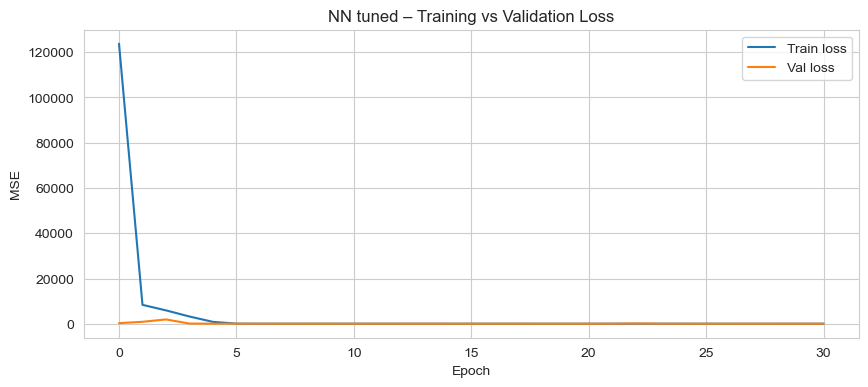

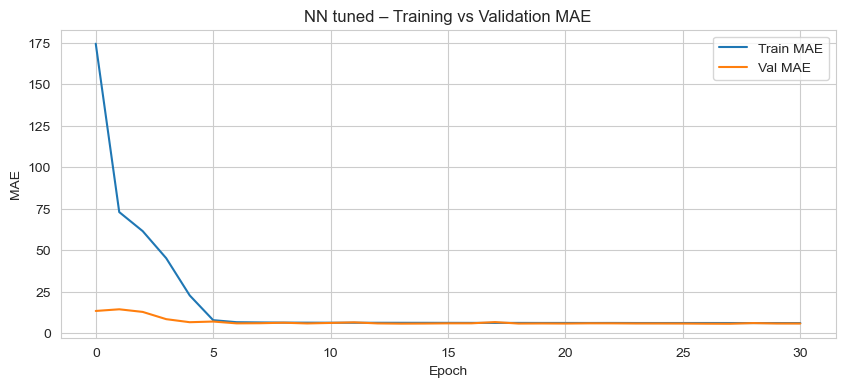

In [13]:
plt.figure(figsize=(10,4))
plt.plot(history_best.history["loss"],     label="Train loss")
plt.plot(history_best.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("NN tuned – Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_best.history["mae"],     label="Train MAE")
plt.plot(history_best.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("NN tuned – Training vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()


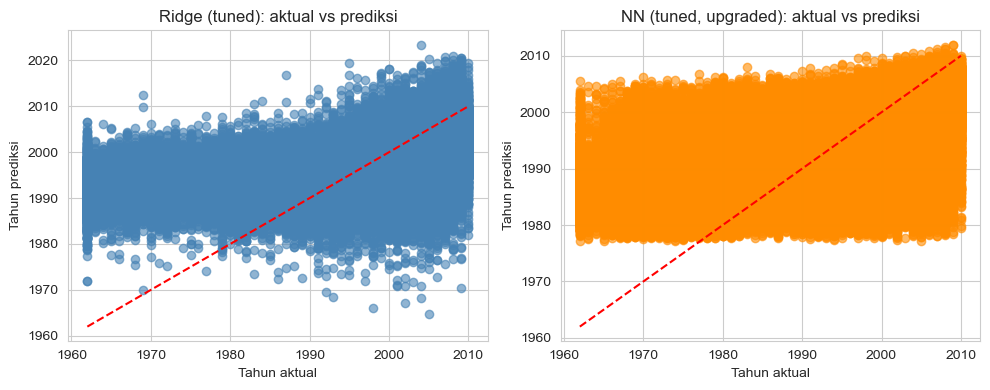

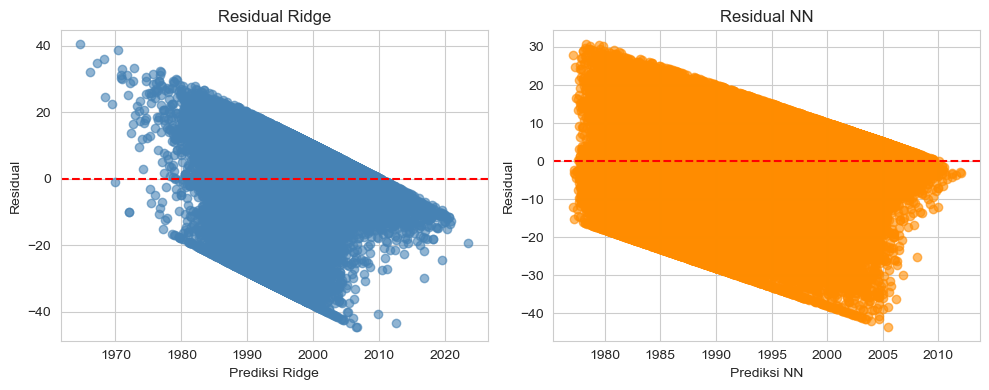

In [14]:
plt.figure(figsize=(10,4))

# Ridge
plt.subplot(1,2,1)
plt.scatter(y_test, ridge_preds, alpha=0.6, color="steelblue")
min_y, max_y = y_test.min(), y_test.max()
plt.plot([min_y, max_y], [min_y, max_y], "r--")
plt.xlabel("Tahun aktual")
plt.ylabel("Tahun prediksi")
plt.title("Ridge (tuned): aktual vs prediksi")

# NN
plt.subplot(1,2,2)
plt.scatter(y_test, nn_preds, alpha=0.6, color="darkorange")
plt.plot([min_y, max_y], [min_y, max_y], "r--")
plt.xlabel("Tahun aktual")
plt.ylabel("Tahun prediksi")
plt.title("NN (tuned, upgraded): aktual vs prediksi")

plt.tight_layout()
plt.show()

# residual
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
res_ridge = y_test - ridge_preds
plt.scatter(ridge_preds, res_ridge, alpha=0.6, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Prediksi Ridge")
plt.ylabel("Residual")
plt.title("Residual Ridge")

plt.subplot(1,2,2)
res_nn = y_test - nn_preds
plt.scatter(nn_preds, res_nn, alpha=0.6, color="darkorange")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Prediksi NN")
plt.ylabel("Residual")
plt.title("Residual NN")

plt.tight_layout()
plt.show()
